# Stage 4 Daily LFP Power and Coherence Analysis

This notebook builds an LFPCollection from Stage 4 Trodes recordings, attaches behavioral event windows, preprocesses selected LFP channels, computes spectral connectivity, reloads saved results, and compares event-locked power and coherence spectra across experimental roles.

Notebook map: environment setup -> helper functions -> LFP metadata -> behavioral events -> LFPCollection creation and preprocessing -> save/reload -> condition labels and event timing QC -> condition-aware spectrum helper -> power analysis -> coherence analysis.


## 1. Environment Setup

Configure GPU support, set the repository root, import analysis modules, and run a CuPy smoke test. On a local workstation, update the HiPerGator-specific paths before running these cells.


In [1]:
# Enable GPU support for spectral_connectivity before importing it.
%env SPECTRAL_CONNECTIVITY_ENABLE_GPU=true

env: SPECTRAL_CONNECTIVITY_ENABLE_GPU=true


In [3]:
# Imports for collection creation, event extraction, plotting, and GPU-backed connectivity.
import os
import sys
# Work from the repository root so relative module paths resolve.
# ---------------- CHANGE THIS PATH TO YOUR DATA ----------------
os.chdir('/blue/npadillacoreano/zishuzhao/diff_fam_social_memory_ephys')
import math
import pickle
import importlib
import cupy as cp
import numpy as np
import pandas as pd
from bidict import bidict
from cupyx.scipy.fft import ifft
from types import SimpleNamespace
from itertools import combinations
from collections import defaultdict
import lfp.lfp_analysis.event_extraction as ee
import lfp.lfp_analysis.plotting as lfplt
from cupyx.scipy.sparse.linalg import svds
from spectral_connectivity import Multitaper, Connectivity
import lfp.lfp_analysis.LFP_collection as LFP_collection

/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# HiPerGator CUDA paths; update or skip this cell on a local workstation.
print(sys.executable)

os.environ["CUDA_PATH"] = "/apps/compilers/cuda/12.4.1"
os.environ["CUDA_HOME"] = "/apps/compilers/cuda/12.4.1"
os.environ["CONDA_PREFIX"] = sys.prefix

print(os.environ.get("CUDA_PATH"))
print(os.environ.get("CUDA_HOME"))
print("sys.prefix:", sys.prefix)

# cuda_bin = r"C:\Users\zhaoz\miniforge3\envs\lfp_env\Library\bin"

# # Add CUDA DLL folder to Windows DLL search path
# os.add_dll_directory(cuda_bin)

# # Add it to PATH for packages that search PATH
# os.environ["PATH"] = cuda_bin + os.pathsep + os.environ["PATH"]

# # Enable GPU mode for spectral_connectivity
# os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"] = "true"

# print("CUDA DLL path added:", cuda_bin)
# print("GPU flag:", os.environ["SPECTRAL_CONNECTIVITY_ENABLE_GPU"])

/blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env/bin/python
/apps/compilers/cuda/12.4.1
/apps/compilers/cuda/12.4.1
sys.prefix: /blue/npadillacoreano/zishuzhao/.conda/envs/lfp_env


In [5]:
# CuPy smoke test: confirms this Jupyter kernel can run GPU operations.
x = cp.array([1, 2, 3])
print(cp.linalg.norm(x))
cp.cuda.Stream.null.synchronize()
print("VS Code Jupyter GPU calculation worked")

3.7416573867739413
VS Code Jupyter GPU calculation worked


## 2. Helper Functions

Small utilities for pickling/unpickling intermediate dictionaries and parsing subject IDs from `merged.rec` filenames.


In [6]:
# File helpers and filename parsing used to build recording metadata dictionaries.
def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl
    Returns:
        none
    """
    with open(file_name, "wb") as file:
        pickle.dump(thing_to_pickle, file)
def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, "rb") as file:
        return pickle.load(file)

# behavior_dicts = {}
def make_recording_to_subj_dict(data_path):
    recording_to_subject = {}
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('merged.rec'):
                subject = str((file.split("_")[-2]).replace('-', '.'))
                recording_to_subject[file] = subject
                # behavior_dicts[file] = {}
    return recording_to_subject

## 3. LFP Metadata

Define the raw recording folder, map each recording to a subject, and map each subject to the selected channel for each brain region. These dictionaries are the metadata backbone for `LFPCollection`.


In [8]:
# Work from the share/eli_coop_ephys root so relative data paths resolve.
# ---------------- CHANGE THIS PATH TO YOUR DATA ----------------
os.chdir('/blue/npadillacoreano/share/eli_coop_ephys')

In [39]:
# LFP recording folder. Each merged.rec becomes one LFPRecording in the collection.
data_path = r"./D7"

# LFPCollection needs two maps: recording file -> subject, and subject -> region channels.
recording_to_subject = make_recording_to_subj_dict(data_path)
subject_to_channel_dict = {}
# Channel numbers are SpikeInterface/Trodes zero-indexed channel IDs for each implanted region.
for subject in recording_to_subject.values():
    if subject == '6.1':
        mpfc = 14
    if subject == '6.3':
        mpfc = 17
    if subject == '2.1':
        mpfc = 18
    if subject == '2.4': #ramping here
        mpfc = 1 
    if subject == '1.3':
        mpfc = 3
    if subject == '1.2': #minimal ramping in channels 2+ 3
        mpfc = 16
    if subject == '4.2':
        mpfc = 18
    if subject == '4.3':
        mpfc = 19
    if subject == '4.4':
        mpfc = 14
    if subject == '4.1':
        mpfc = 9
    subject_to_channel_dict[subject] = {'mPFC': mpfc, 'IC': 27, 'NAc': 28, 'MD': 29, 'LH': 30, 'BLA': 31}

# Channel mapping file for the LFPCollection. Not updated so far, but could be used to automatically generate the subject_to_channel_dict above.
# df = pd.read_excel(r"./lfp/input/channel_mapping.xlsx")
# spike_cols = [col for col in df.columns if 'spike_interface_' in col.lower()]
# print(df)


## 4. Behavioral Events

Load Stage 4 behavioral event windows from the pickle file and rename keys so they exactly match the `.rec` filenames used by the LFP objects.


In [40]:
# Load Stage 4 behavioral event windows and attach them to matching .rec filenames.
# Keys must match the merged.rec names exactly so LFPCollection can assign events.

# Get event dictionaries for all recordings
# ---------------- CHANGE THIS PATH TO YOUR DATA ----------------
all_recordings = unpickle_this(r"./D7/Stage4_D7.pkl")
event = {f"{key}.rec": value for key, value in all_recordings.items()}
print(event.keys())



dict_keys(['20250516_095627_Stage4_D7_1-2_merged.rec', '20250516_095627_Stage4_D7_1-3_merged.rec', '20250516_111920_Stage4_D7_2-1_merged.rec', '20250516_111920_Stage4_D7_2-4_merged.rec', '20250516_135729_Stage4_D7_4-1_merged.rec', '20250516_135729_Stage4_D7_4-2_merged.rec', '20250516_135729_Stage4_D7_4-3_merged.rec', '20250516_135729_Stage4_D7_4-4_merged.rec', '20250516_162851_Stage4_D7_6-1_merged.rec', '20250516_162851_Stage4_D7_6-3_merged.rec'])


## 5. LFPCollection Creation and Preprocessing

Create the collection from raw Trodes recordings, then QC and preprocess traces. Preprocessing scales voltage, removes large artifacts with a MAD-z threshold, and RMS-normalizes each region trace.


In [41]:
# Build the collection from raw Trodes recordings, selected channels, and event windows.
# threshold=5 removes large MAD-z-scored artifacts during preprocessing.

collection = LFP_collection.LFPCollection(subject_to_channel_dict, 
                                          data_path, 
                                          recording_to_subject, 5, 
                                          recording_to_event_dict = event)


Processing 20250516_135729_Stage4_D7_4-2_merged.rec
Processing 20250516_162851_Stage4_D7_6-3_merged.rec
Processing 20250516_111920_Stage4_D7_2-4_merged.rec
Processing 20250516_135729_Stage4_D7_4-4_merged.rec
Processing 20250516_095627_Stage4_D7_1-2_merged.rec
Processing 20250516_135729_Stage4_D7_4-3_merged.rec
Processing 20250516_135729_Stage4_D7_4-1_merged.rec
Processing 20250516_111920_Stage4_D7_2-1_merged.rec
Processing 20250516_095627_Stage4_D7_1-3_merged.rec
Processing 20250516_162851_Stage4_D7_6-1_merged.rec


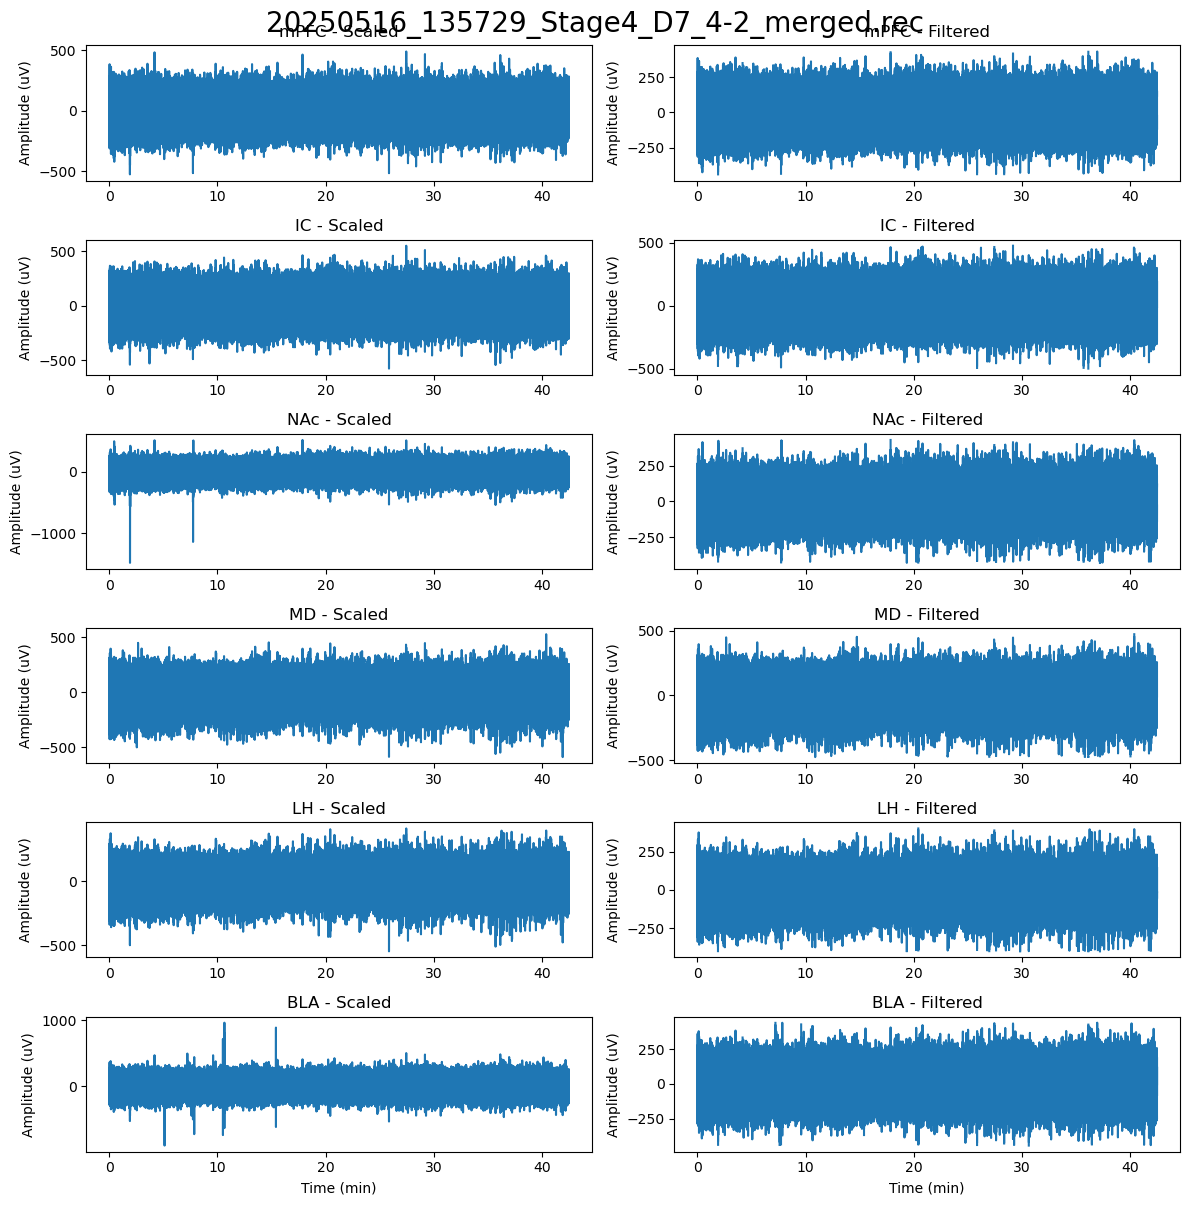

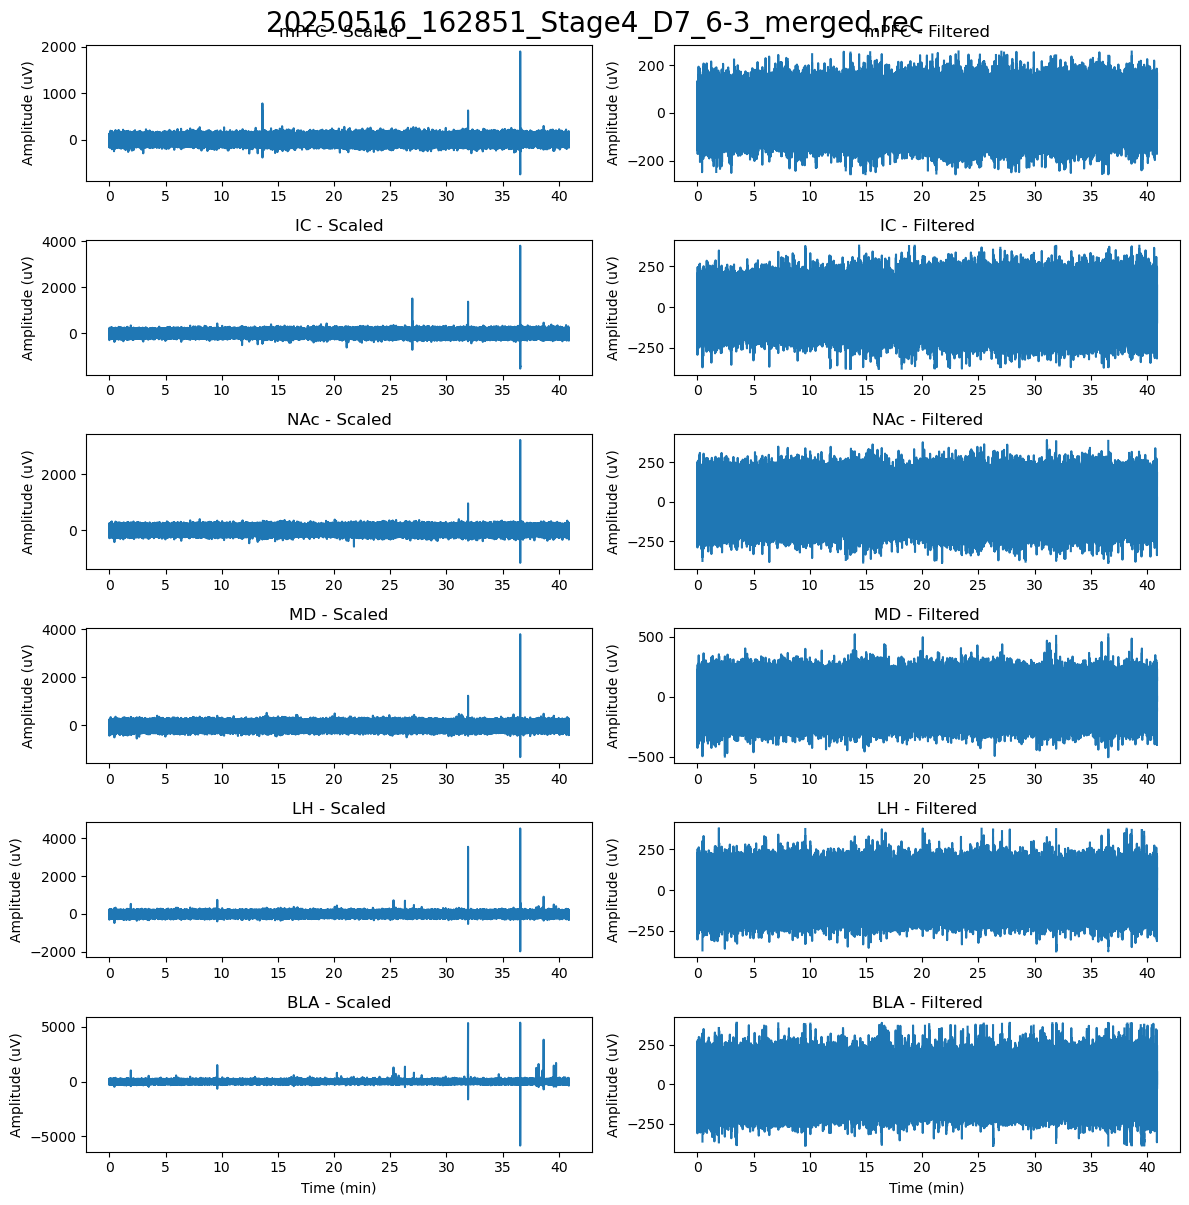

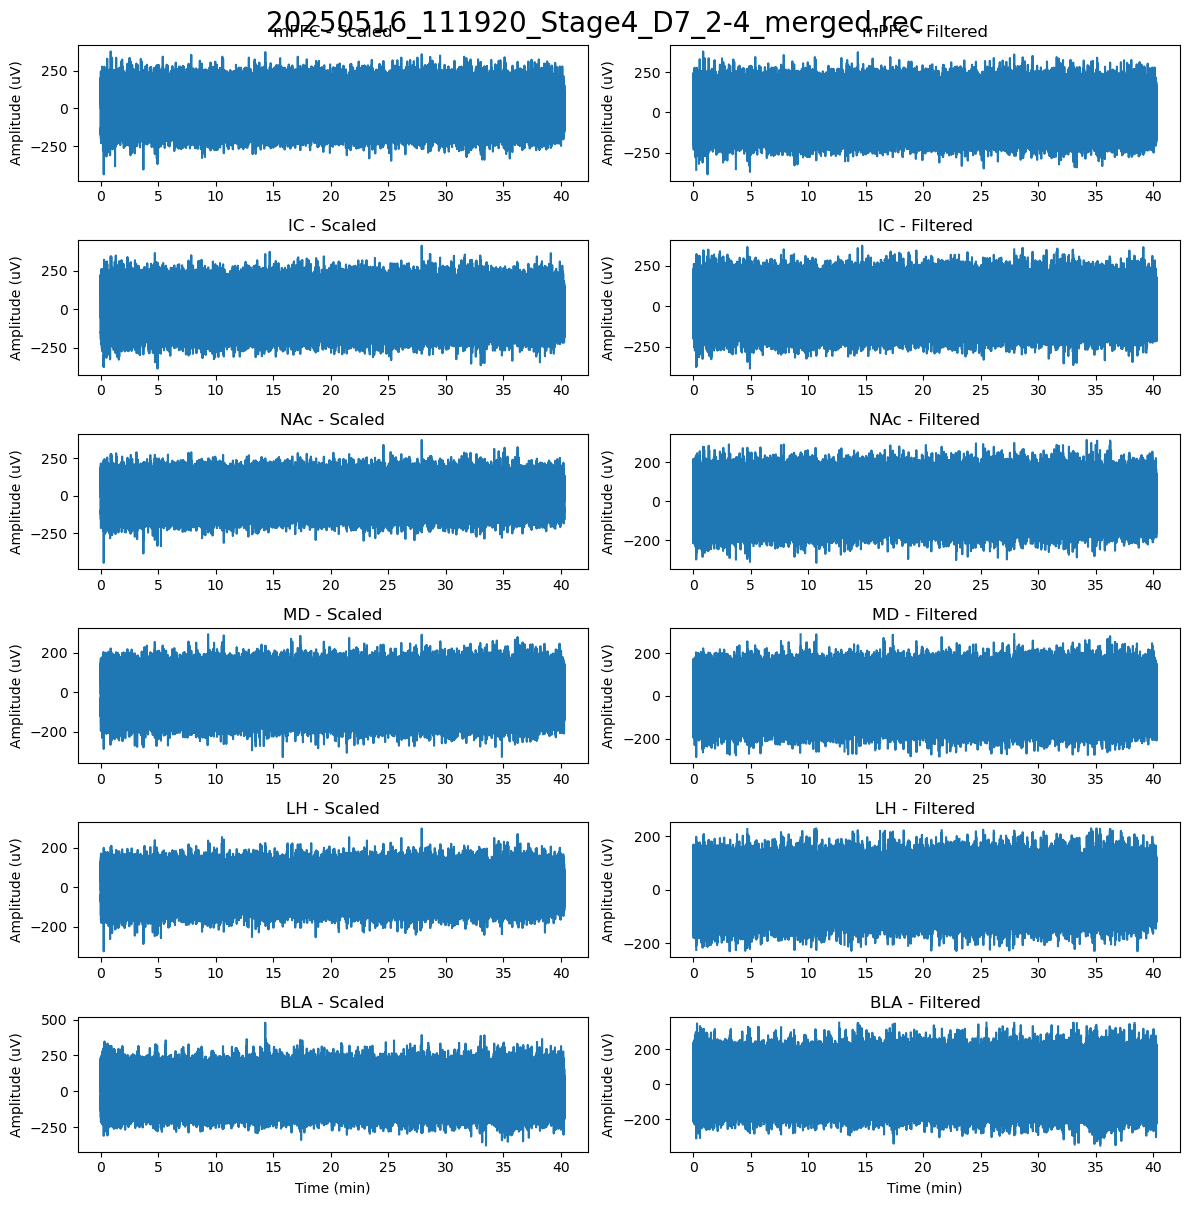

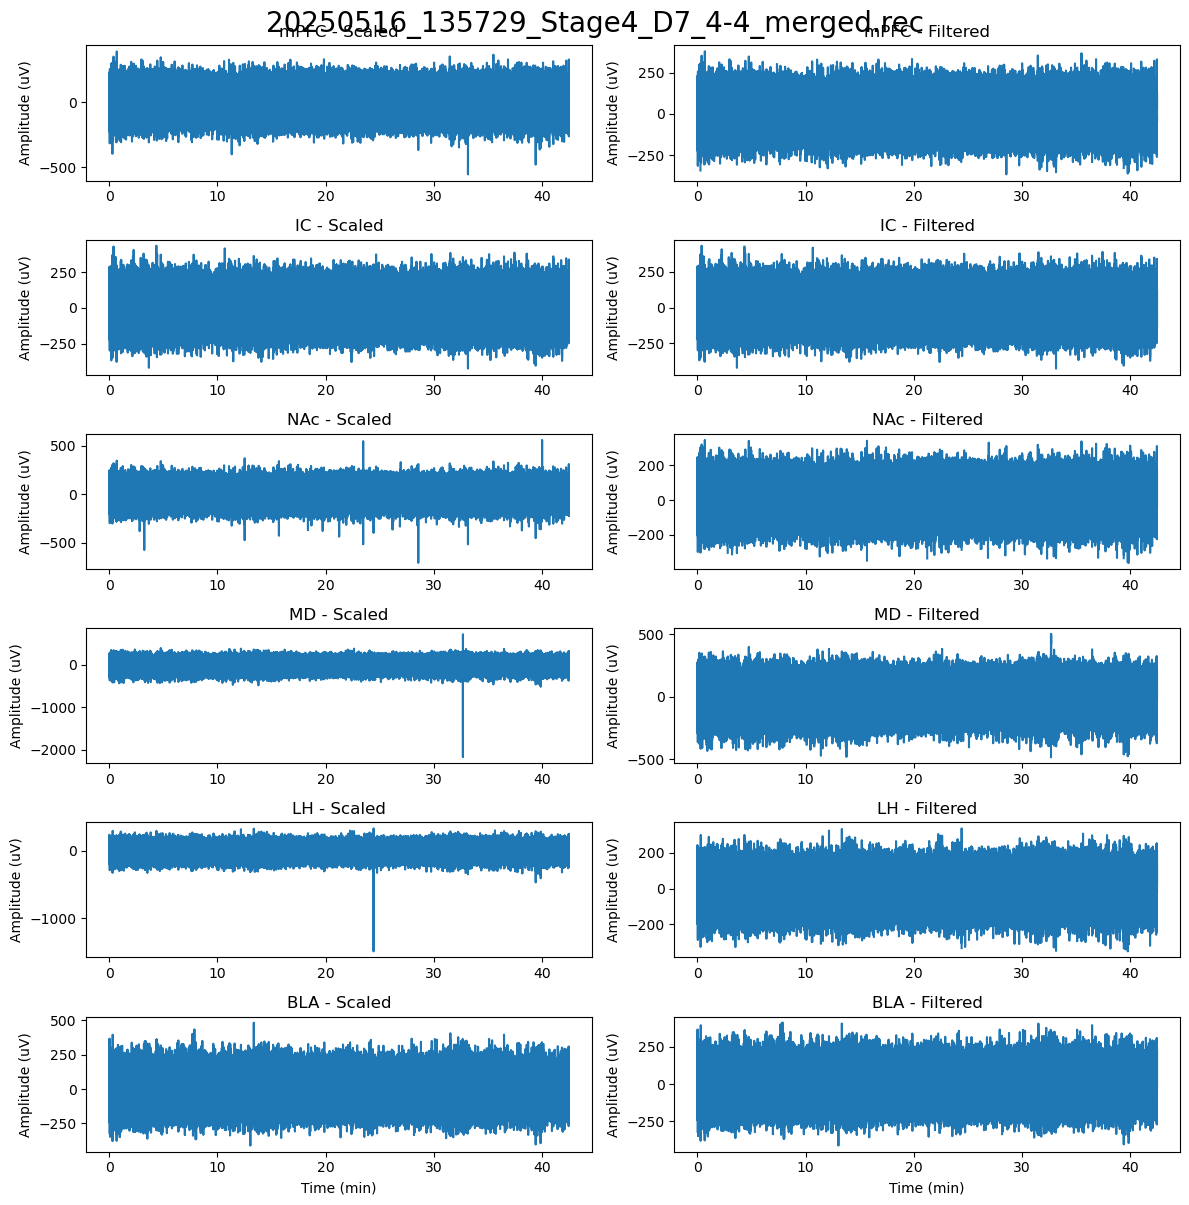

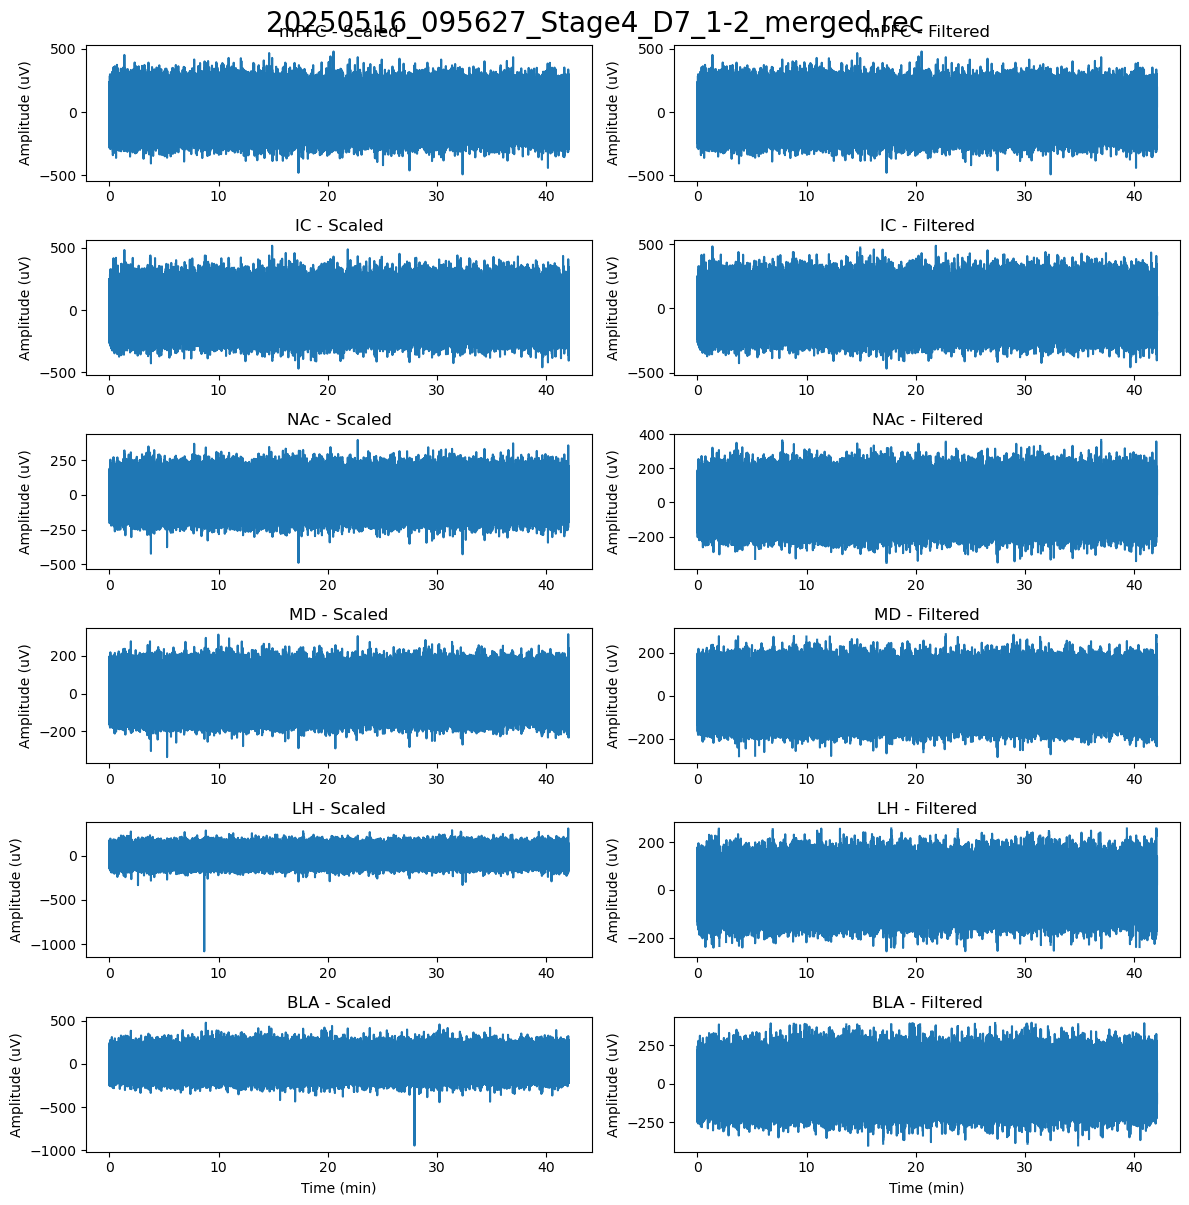

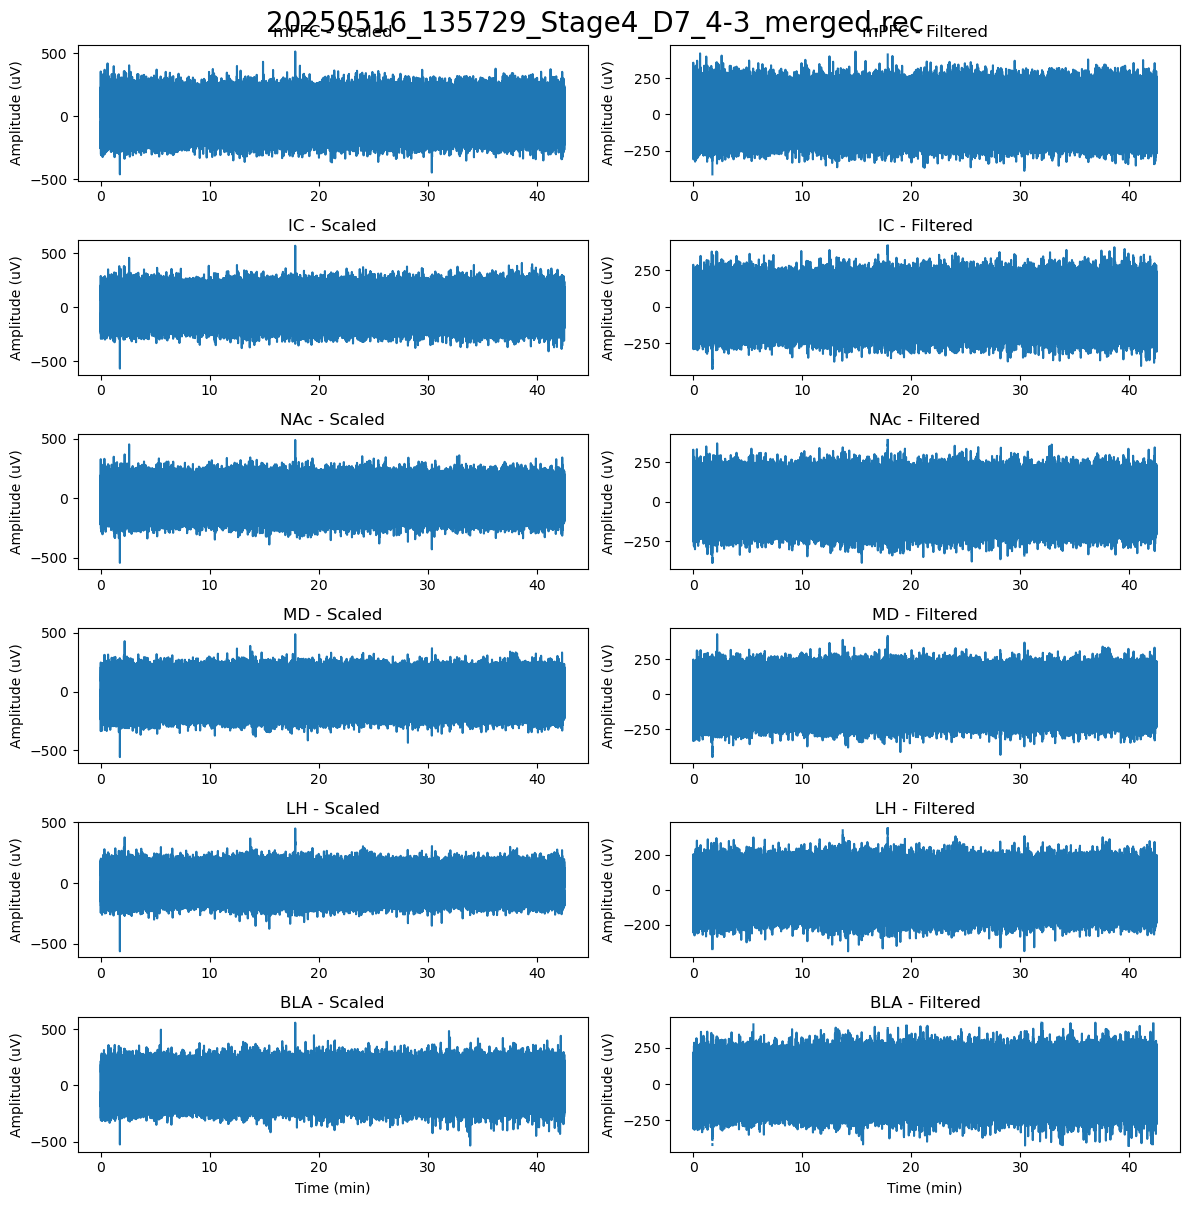

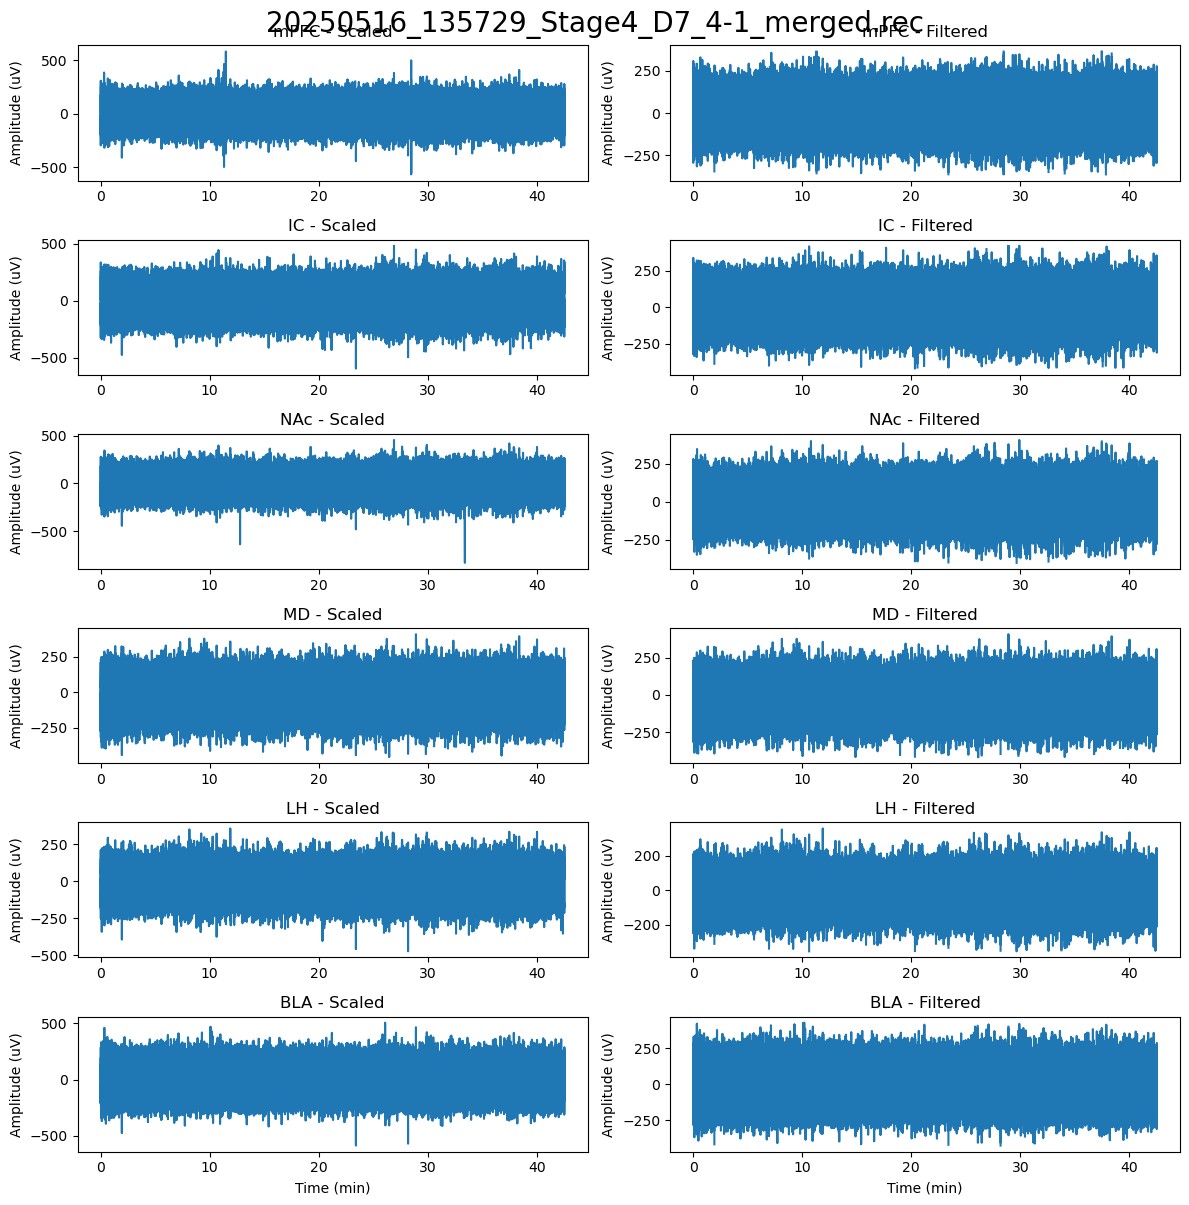

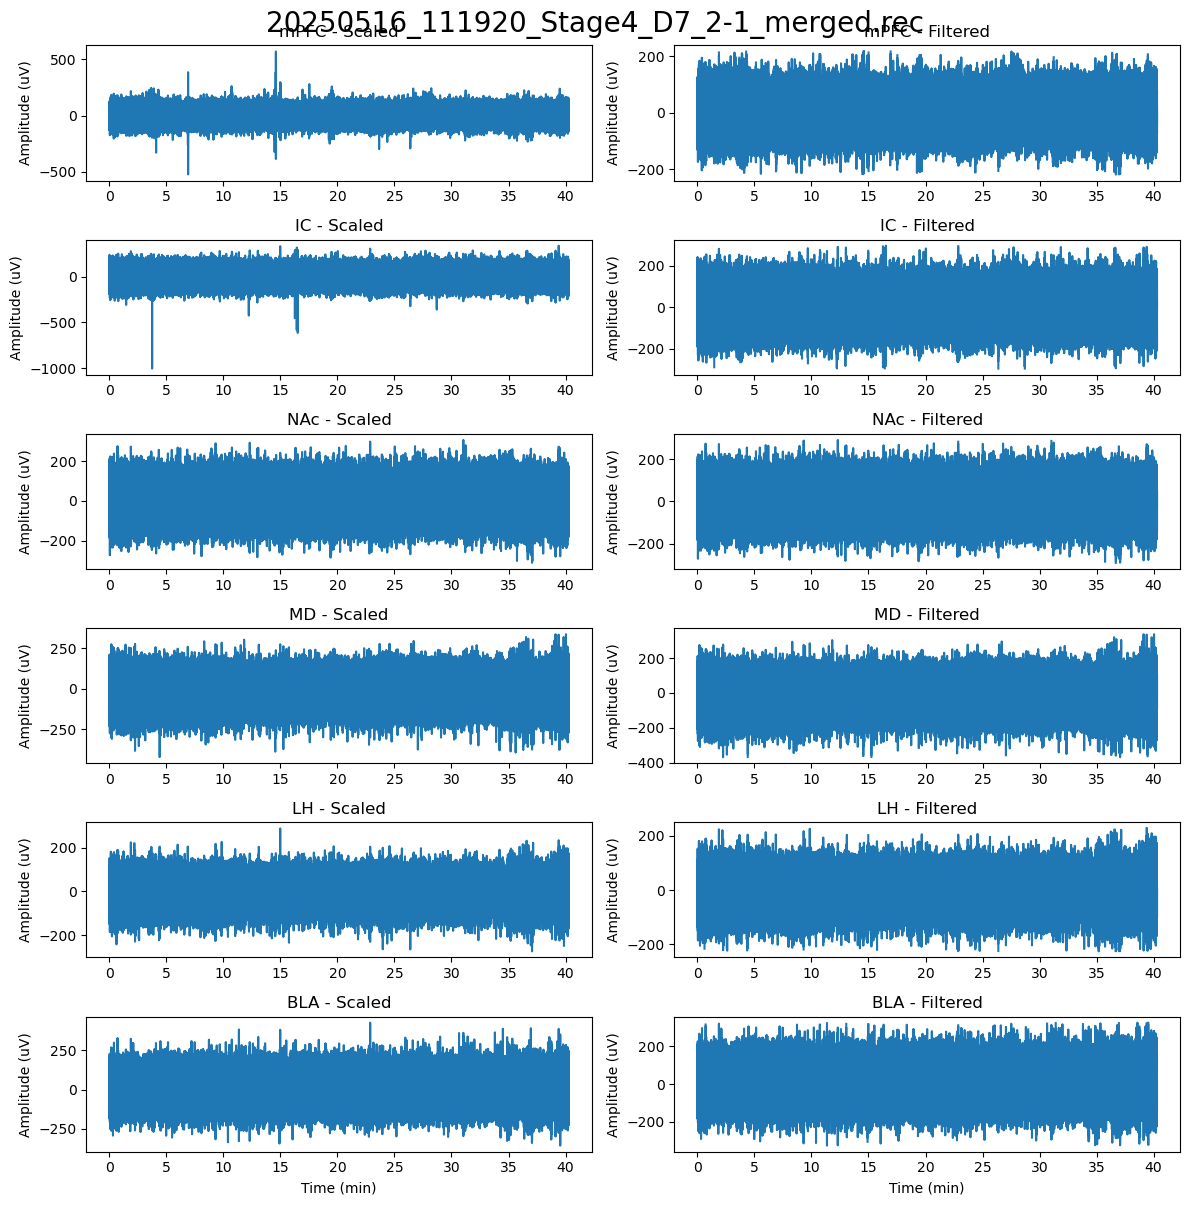

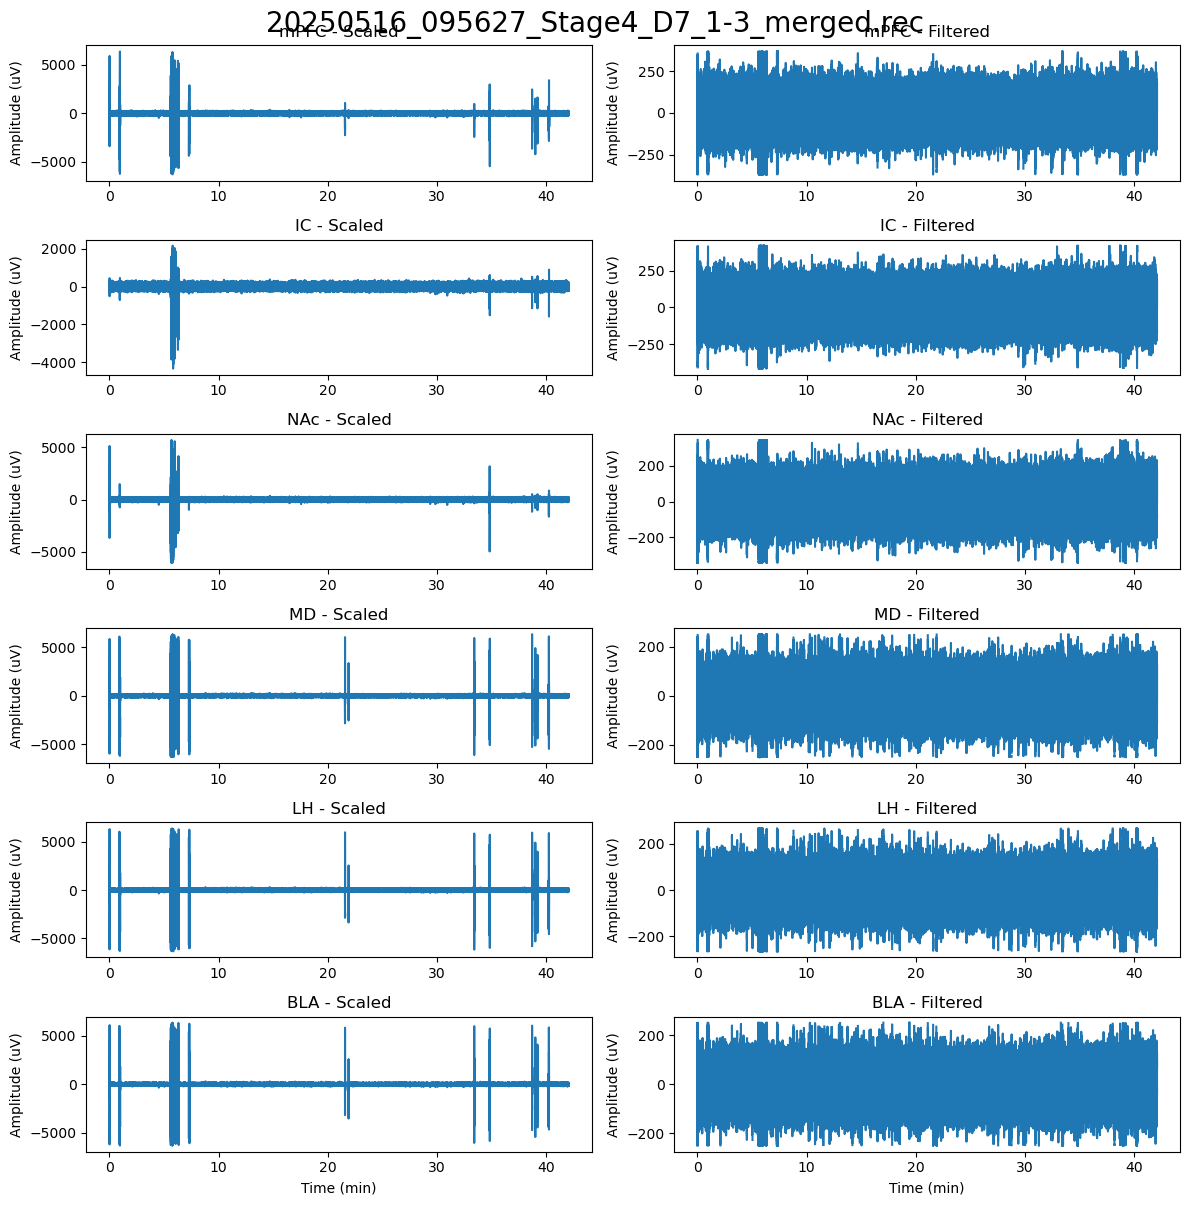

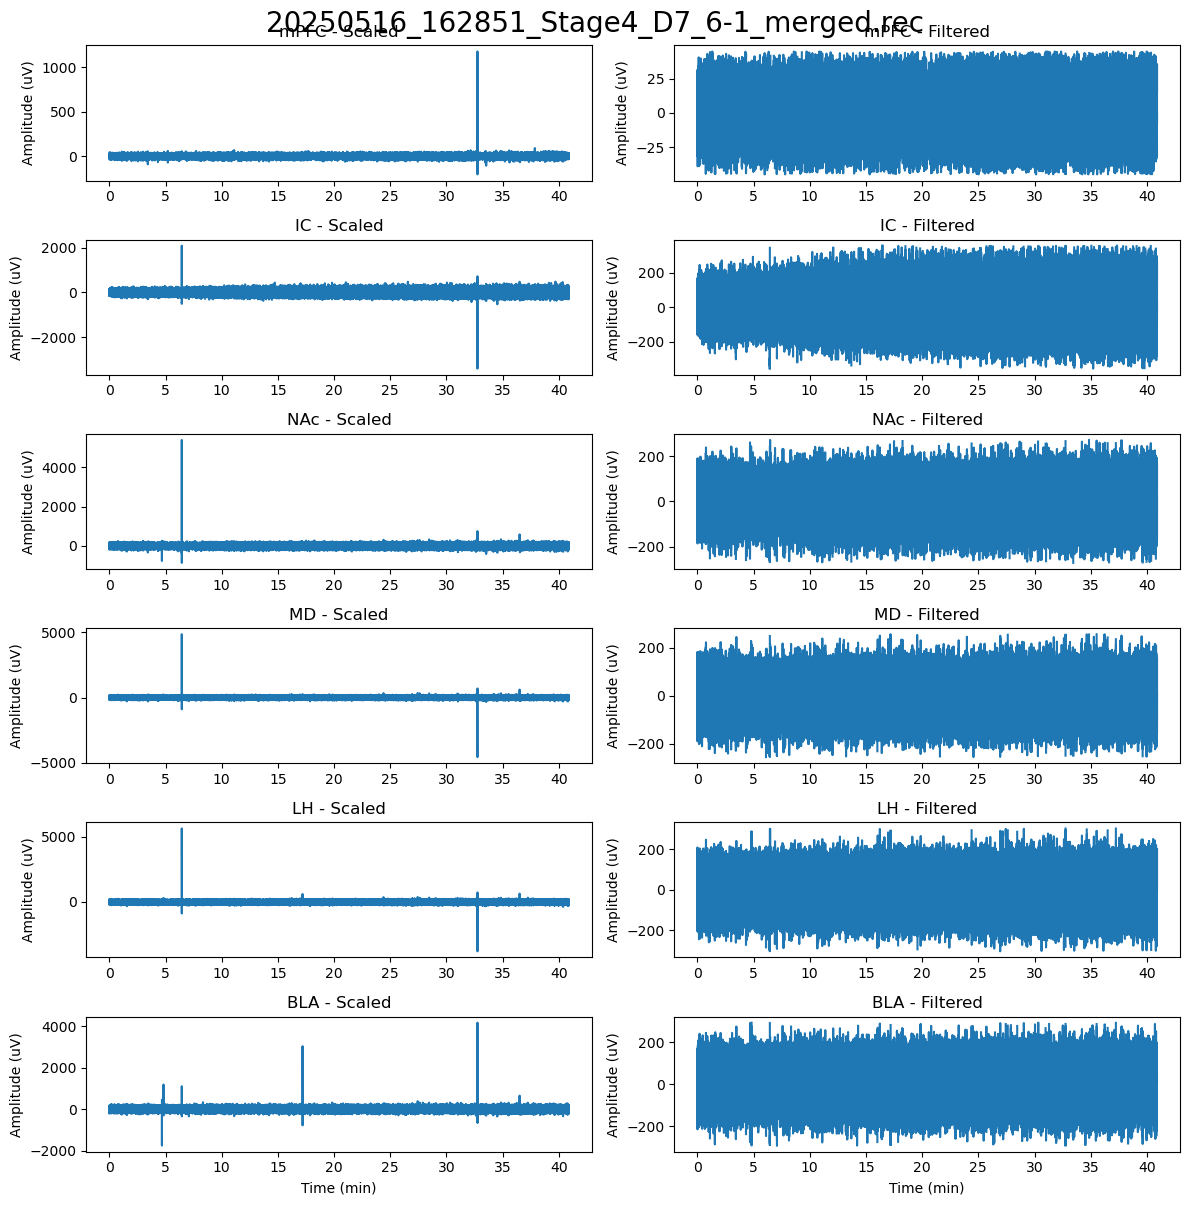

In [42]:
# Visual QC for raw/filtered traces before committing to preprocessing.
collection.diagnostic_plots(threshold = 5)

In [43]:
# Scale voltage, robust-z filter artifacts, and RMS-normalize traces per region.
collection.preprocess(threshold = 5)

  0%|          | 0/10 [00:00<?, ?it/s]

processing 20250516_135729_Stage4_D7_4-2_merged.rec


 10%|█         | 1/10 [00:00<00:05,  1.60it/s]

RMS Traces calculated
processing 20250516_162851_Stage4_D7_6-3_merged.rec


 20%|██        | 2/10 [00:01<00:04,  1.62it/s]

...

RMS Traces calculated
processing 20250516_095627_Stage4_D7_1-3_merged.rec


 90%|█████████ | 9/10 [00:05<00:00,  1.77it/s]

RMS Traces calculated
processing 20250516_162851_Stage4_D7_6-1_merged.rec


100%|██████████| 10/10 [00:05<00:00,  1.70it/s]

RMS Traces calculated


## 6. Spectral Connectivity Computation

Compute multitaper spectral measures for each recording. This notebook uses both power and coherence, but `calculate_all()` also computes Granger causality.


In [44]:
# Compute multitaper spectra for each recording.
# This calculates power, coherence, and Granger; for coherence-only runs, calculate_coherence() is cheaper.
collection.calculate_all()

  0%|          | 0/10 [00:00<?, ?it/s]

Power Calculated


 10%|█         | 1/10 [00:00<00:04,  1.88it/s]

Coherence calcualatd
Power Calculated


 20%|██        | 2/10 [00:00<00:03,  2.40it/s]

...

Granger causality calculated


Maximum iterations reached. 4894 of 5049 converged
Maximum iterations reached. 4900 of 5049 converged
Maximum iterations reached. 4832 of 5049 converged
Maximum iterations reached. 4876 of 5049 converged
Maximum iterations reached. 4824 of 5049 converged
Maximum iterations reached. 4932 of 5049 converged
Maximum iterations reached. 4832 of 5049 converged
Maximum iterations reached. 4879 of 5049 converged
Maximum iterations reached. 4824 of 5049 converged
Maximum iterations reached. 4830 of 5049 converged
Maximum iterations reached. 4875 of 5049 converged
Maximum iterations reached. 4821 of 5049 converged
Maximum iterations reached. 4824 of 5049 converged
Maximum iterations reached. 4823 of 5049 converged
Maximum iterations reached. 4821 of 5049 converged
 90%|█████████ | 9/10 [04:15<00:28, 28.40s/it]

Granger causality calculated


Maximum iterations reached. 4134 of 4907 converged
Maximum iterations reached. 4200 of 4907 converged
Maximum iterations reached. 4202 of 4907 converged
Maximum iterations reached. 4215 of 4907 converged
Maximum iterations reached. 4197 of 4907 converged
Maximum iterations reached. 4671 of 4907 converged
Maximum iterations reached. 4676 of 4907 converged
Maximum iterations reached. 4703 of 4907 converged
Maximum iterations reached. 4683 of 4907 converged
Maximum iterations reached. 4785 of 4907 converged
Maximum iterations reached. 4812 of 4907 converged
Maximum iterations reached. 4788 of 4907 converged
Maximum iterations reached. 4794 of 4907 converged
Maximum iterations reached. 4796 of 4907 converged
Maximum iterations reached. 4825 of 4907 converged
100%|██████████| 10/10 [04:43<00:00, 28.34s/it]

Granger causality calculated


## 7. Save and Reload Processed Collection

Persist collection metadata to JSON and recording-level arrays/events to H5 so downstream analysis can reload results without reprocessing raw Trodes files.


In [45]:
# Save metadata as JSON and each recording's arrays/events as H5 for faster reloads.
collection.save_to_json(r"./D7/D7_lfp_collection")


### Reload Entry Point

Reload the saved collection from disk. Use this as the starting point when spectral features have already been computed and saved.


In [6]:
# Reload the saved collection so downstream analysis does not need raw Trodes files.
collection=LFP_collection.LFPCollection.load_collection(r"other_peoples_sutff/Catherine/lfp_eli/D8/D8_lfp_collection/lfp_collection.json")

## 8. Condition Labels

Assign each recording to an experimental role using the animal ID embedded in the filename: subject alone, subject with recipient, recipient, or unknown.


In [19]:
# Group recordings by experimental role parsed from the animal ID in the filename.
# These groups define which recordings are averaged together in condition_event_spectrum().

condition_dict = defaultdict(list)

recipients = {"1-3", "2-1", "4-2", "4-1"}
subject_with_recipient = {"1-2", "2-4", "4-4", "4-3"}
subject_alone = {"6-1", "6-3"}

for recording in collection.recordings:
    # Filename pattern: date_time_Stage4_D8_<animal-id>_merged.rec
    animal_id = recording.name.split("_")[4]

    if animal_id in subject_alone:
        recording.condition = "subject alone"
        condition_dict["subject alone"].append(recording.name)

    elif animal_id in subject_with_recipient:
        recording.condition = "subject with recipient"
        condition_dict["subject with recipient"].append(recording.name)

    elif animal_id in recipients:
        recording.condition = "recipient"
        condition_dict["recipient"].append(recording.name)

    else:
        recording.condition = "unknown"
        condition_dict["unknown"].append(recording.name)
        
print(condition_dict)

defaultdict(<class 'list'>, {'subject with recipient': ['20250511_144904_Stage4_D3_4-4_merged.rec', '20250511_144904_Stage4_D3_4-3_merged.rec', '20250510_100439_Stage4_D3_1-2_merged.rec', '20250510_100439_Stage4_D3_2-4_merged.rec'], 'subject alone': ['20250510_112820_Stage4_D3_6-1_merged.rec', '20250510_112820_Stage4_D3_6-3_merged.rec'], 'recipient': ['20250511_144904_Stage4_D3_4-2_merged.rec', '20250511_144904_Stage4_D3_4-1_merged.rec', '20250510_100439_Stage4_D3_1-3_merged.rec', '20250510_100439_Stage4_D3_2-1_merged.rec']})


## 9. Event Timing QC

Convert event times into milliseconds and check that event windows fall within the computed spectral time bins. This catches unit mismatches and out-of-range events before averaging.


In [20]:
# Convert behavioral event times from seconds to milliseconds.
# event_extraction bins events using recording.timestep * 1000, so units must be ms.

for recording in collection.recordings:
    for event_name, events in recording.event_dict.items():
        recording.event_dict[event_name] = np.asarray(events) * 1000

In [21]:
# QC check for subject-alone events: verifies event windows fall inside computed spectra.
# Zero-width or out-of-range bins indicate event timing/unit problems.

for recording in collection.recordings:
    if recording.name in condition_dict["subject alone"]:
        print(recording.name)
        freq_timebin = recording.timestep * 1000
        recording_duration_ms = recording.power.shape[0] * freq_timebin

        print("  recording duration ms:", recording_duration_ms)

        for event_name in ["selfish nose poke", "coop nose poke"]:
            events = np.asarray(recording.event_dict[event_name])

            pre_indices = np.ceil(events[:, 0] / freq_timebin).astype(int)
            post_indices = np.ceil(events[:, 1] / freq_timebin).astype(int)
            widths = post_indices - pre_indices
            within = post_indices < recording.power.shape[0]

            print(event_name)
            print("  raw start min/max:", np.nanmin(events[:, 0]), np.nanmax(events[:, 0]))
            print("  raw stop min/max:", np.nanmin(events[:, 1]), np.nanmax(events[:, 1]))
            print("  raw duration min/max:", np.nanmin(events[:, 1] - events[:, 0]), np.nanmax(events[:, 1] - events[:, 0]))
            print("  post index min/max:", np.nanmin(post_indices), np.nanmax(post_indices))
            print("  within recording:", np.sum(within), "of", len(events))
            print("  bin width min/max:", np.nanmin(widths), np.nanmax(widths))
            print("  zero-width:", np.sum(widths <= 0), "of", len(events))

20250510_112820_Stage4_D3_6-1_merged.rec
  recording duration ms: 2444500.0
selfish nose poke
  raw start min/max: 91210.75 2183017.4000000004
  raw stop min/max: 91350.75 2183257.65
  raw duration min/max: 79.75000000005821 1060.0
  post index min/max: 183 4367
  within recording: 79 of 79
  bin width min/max: 0 2
  zero-width: 41 of 79
coop nose poke
  raw start min/max: 79700.59999999999 2334819.1999999997
  raw stop min/max: 80130.6 2335949.35
  raw duration min/max: 39.70000000001164 2090.0500000002794
  post index min/max: 161 4672
  within recording: 180 of 180
  bin width min/max: 0 4
  zero-width: 77 of 180
20250510_112820_Stage4_D3_6-3_merged.rec
  recording duration ms: 2444500.0
selfish nose poke
  raw start min/max: 80850.84999999999 2202697.65
  raw stop min/max: 81030.75 2203337.5
  raw duration min/max: 40.0 2890.1999999999534
  post index min/max: 163 4407
  within recording: 158 of 158
  bin width min/max: 0 6
  zero-width: 96 of 158
coop nose poke
  raw start min/max

## 10. Condition-Aware Event Spectrum Helper

`condition_event_spectrum()` filters the collection to one or more experimental roles, calls `ee.average_events()`, and optionally plots the resulting spectrum. Define this helper before running the Power or Coherence analysis cells below.


In [22]:
# Helper for condition-specific spectra: filters recordings by condition, then reuses ee.average_events().
# Returned arrays stay separated by recording: power [freq, region], coherence/granger [freq, region, region].

# CONDITION-AWARE EVENT SPECTRUM HELPER

def condition_event_spectrum(
    lfp_collection,
    condition_recordings,
    selected_condition,
    events,
    mode='power',
    baseline=None,
    event_len=None,
    pre_window=0,
    post_window=0,
    regions=None,
    freq_range=None,
    plot=True,
):
    if isinstance(selected_condition, str):
        selected_conditions = [selected_condition]
    else:
        selected_conditions = list(selected_condition)

    missing_conditions = [condition for condition in selected_conditions if condition not in condition_recordings]
    if missing_conditions:
        raise ValueError(f"Condition(s) not found in condition_recordings: {missing_conditions}")

    # Flatten selected condition groups into a unique list of recording filenames.
    selected_recording_names = []
    for condition in selected_conditions:
        selected_recording_names.extend(condition_recordings[condition])
    selected_recording_names = list(dict.fromkeys(selected_recording_names))

    selected_recording_set = set(selected_recording_names)
    filtered_recordings = [
        recording
        for recording in lfp_collection.recordings
        if recording.name in selected_recording_set
    ]

    if not filtered_recordings:
        raise ValueError(
            f"No recordings for selected_condition={selected_condition} were found in this LFP collection."
        )

    print(
        f"Calculating {mode} event spectrum for condition(s) {selected_conditions} "
        f"using {len(filtered_recordings)} recording(s)."
    )

    # SimpleNamespace gives ee.average_events() the collection-like attributes it needs.
    filtered_collection = SimpleNamespace(
        recordings=filtered_recordings,
        brain_region_dict=lfp_collection.brain_region_dict,
    )

    # Average within each recording first, then keep recordings separate for group summaries/SEM.
    event_averages = ee.average_events(
        filtered_collection,
        events=events,
        mode=mode,
        baseline=baseline,
        event_len=event_len,
        pre_window=pre_window,
        post_window=post_window,
        plot=False,
    )


    if plot:
        lfplt.plot_event_spectrum(
            lfp_collection,
            event_averages,
            mode=mode,
            regions=regions,
            freq_range=freq_range,
        )

    return event_averages


## 11. Power Analysis

### 1. Selfish vs Coop Light for Subject with Recipient

Calculating power event spectrum for condition(s) ['subject with recipient'] using 4 recording(s).


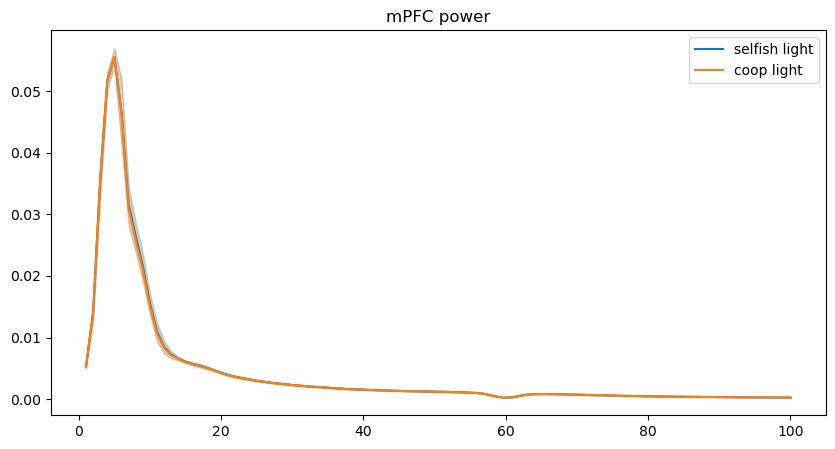

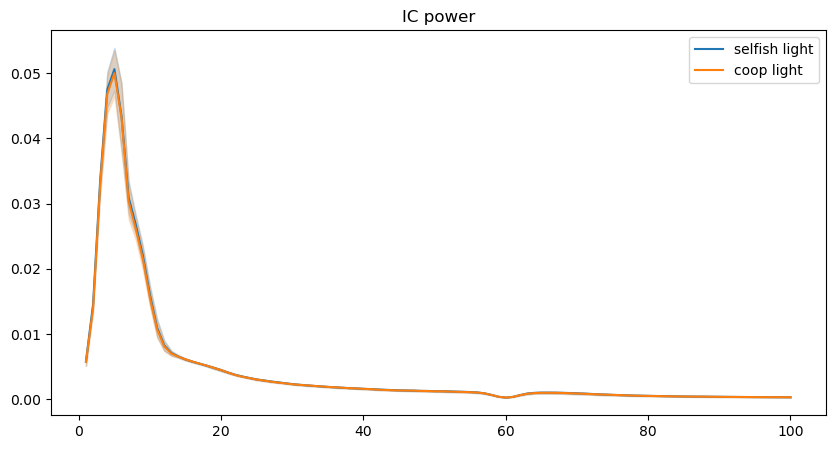

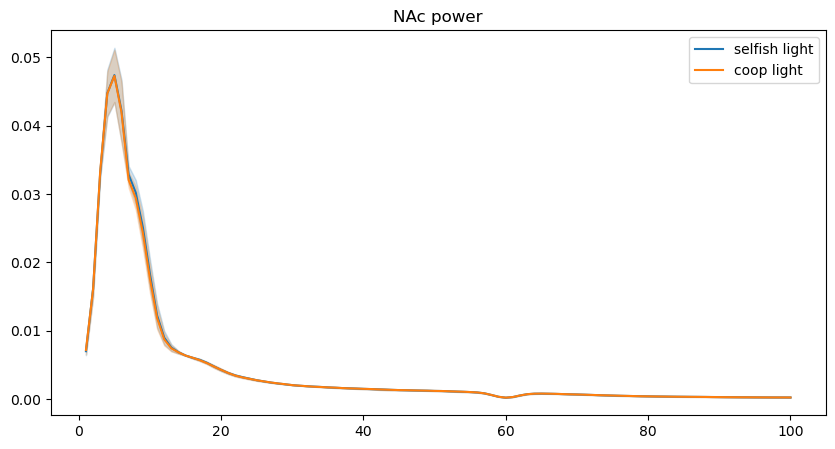

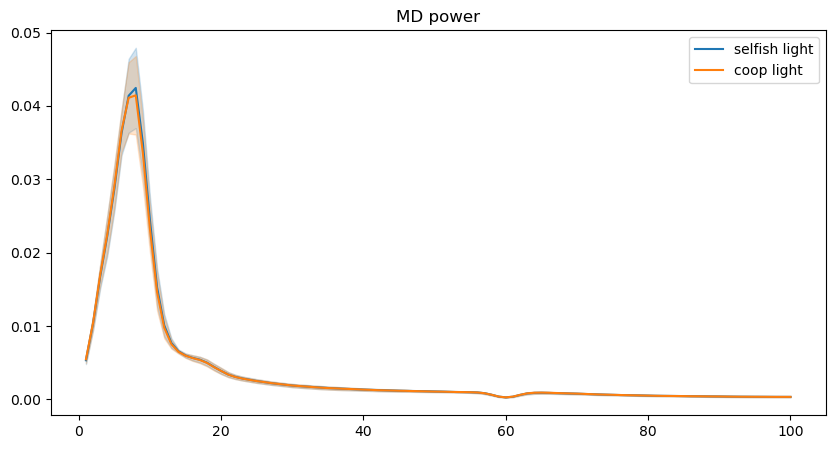

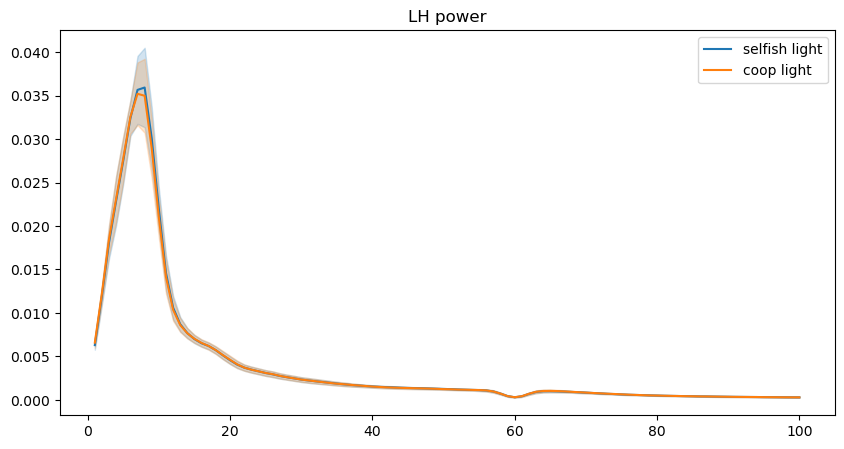

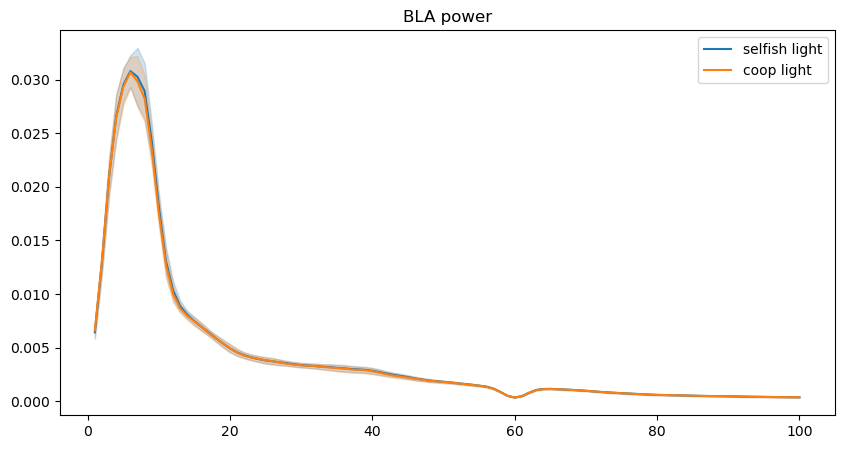

In [23]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject with recipient',
    events=['selfish light', 'coop light'],
    mode='power',
)

### 2. Selfish vs Coop Light for Subjects Alone


In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject alone',
    events=['selfish light', 'coop light'],
    mode='power',
)

### 3. Selfish vs Coop Light for Recipients

In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='recipient',
    events=['selfish light', 'coop light'],
    mode='power',
)

### 4. Selfish vs Coop Nose Pokes for Subjects Paired with Recipients


In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject with recipient',
    events=['selfish nose poke', 'coop nose poke'],
    mode='power',
)

### 5. Selfish vs Coop Nose Pokes for Subjects Alone


In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject alone',
    events=['selfish nose poke', 'coop nose poke'],
    mode='power',
)

## 12. Coherence Analysis

Use the same condition-aware helper to compare event-locked coherence spectra for selfish vs cooperative light events. Coherence outputs are per-recording arrays with shape `[freq, region, region]`.


### 1. Selfish vs Coop Light For Subjects Paired with Recipients


In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject with recipient',
    events=['selfish light', 'coop light'],
    mode='coherence',
)

### 2. Selfish vs Coop Light For Subjects Alone

Calculating coherence event spectrum for condition(s) ['subject alone'] using 2 recording(s).


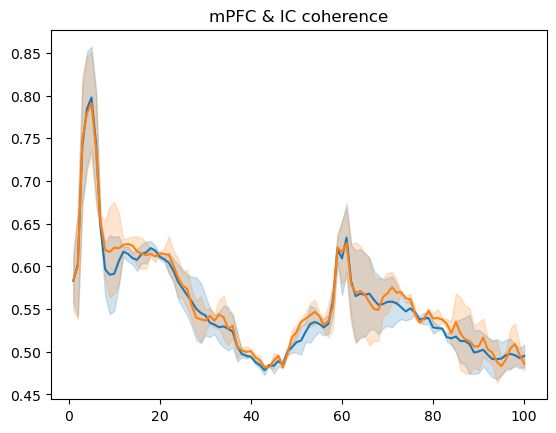

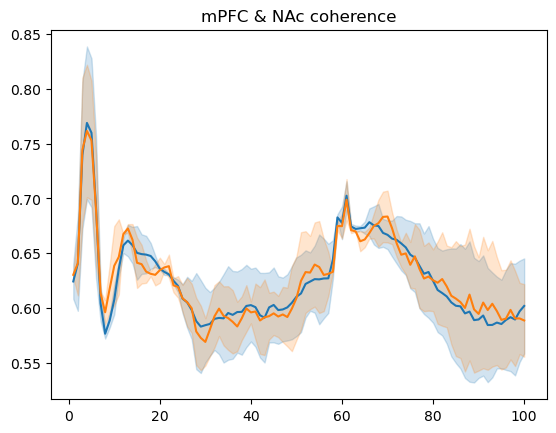

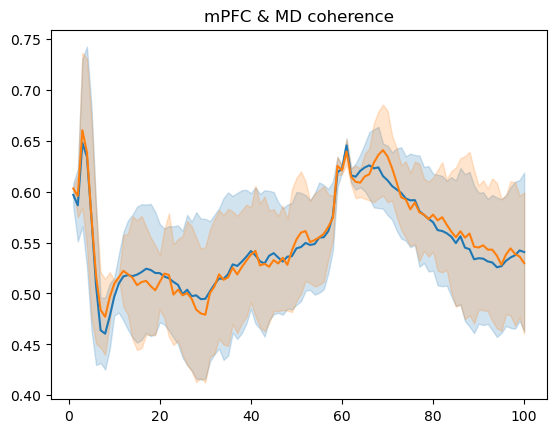

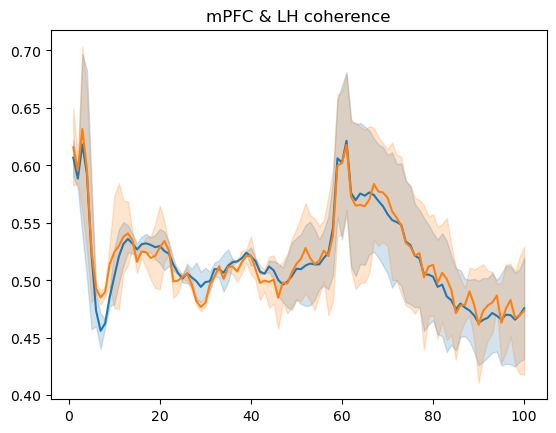

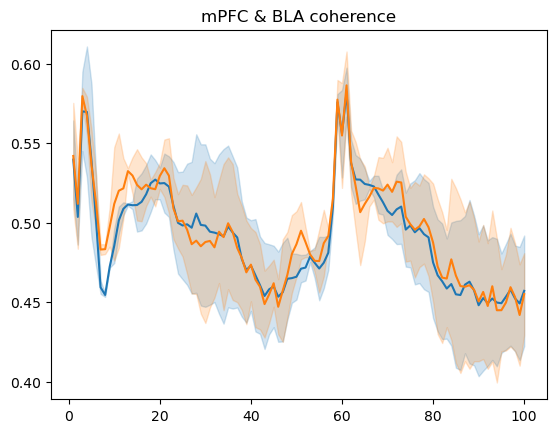

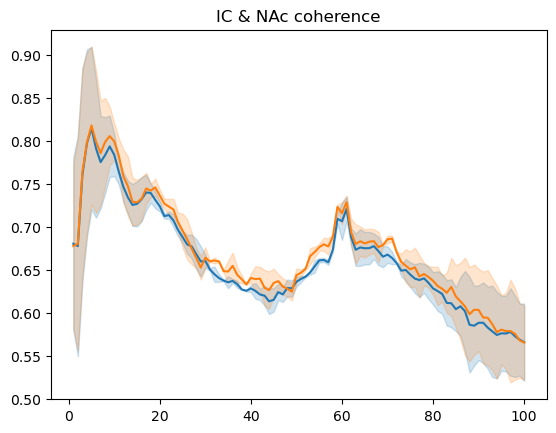

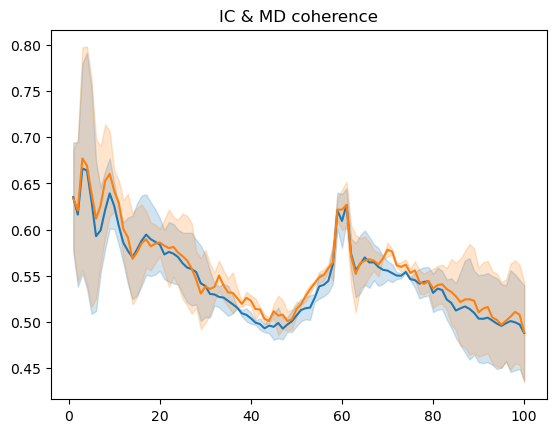

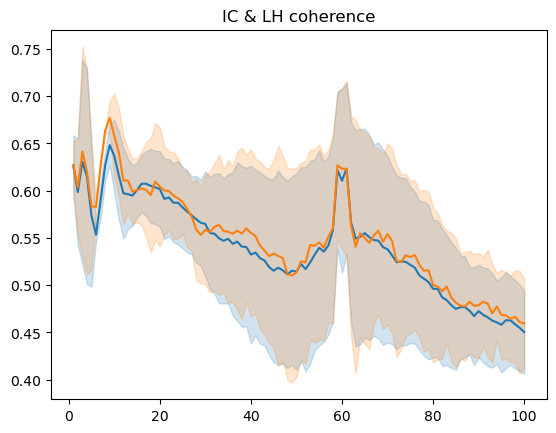

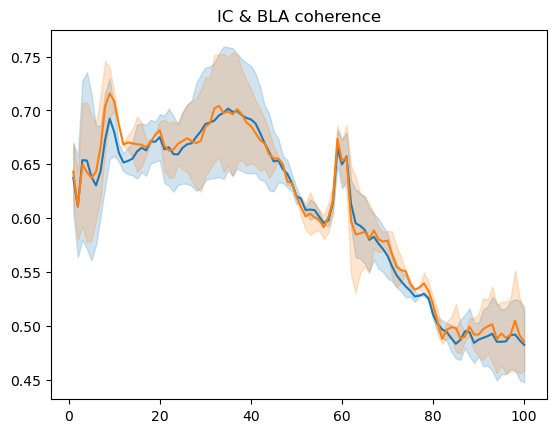

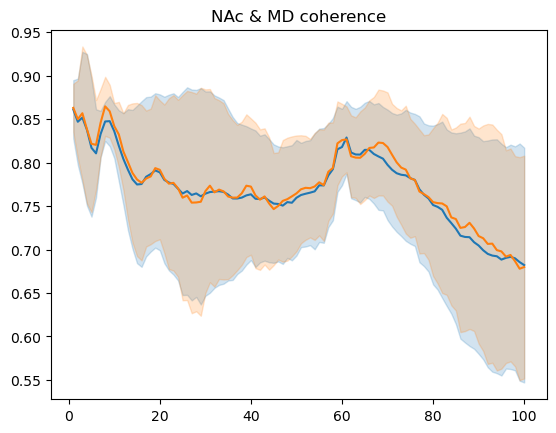

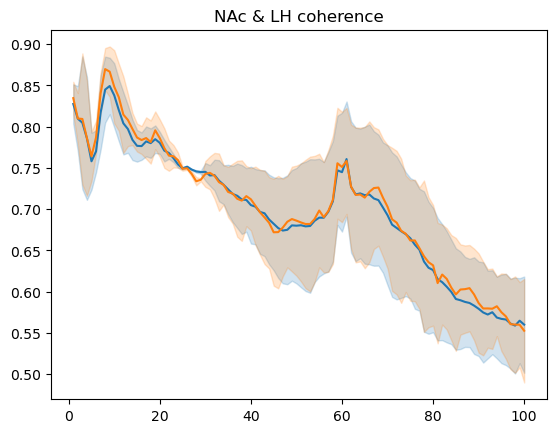

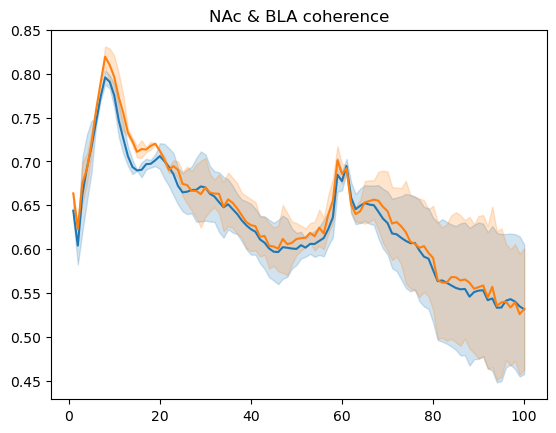

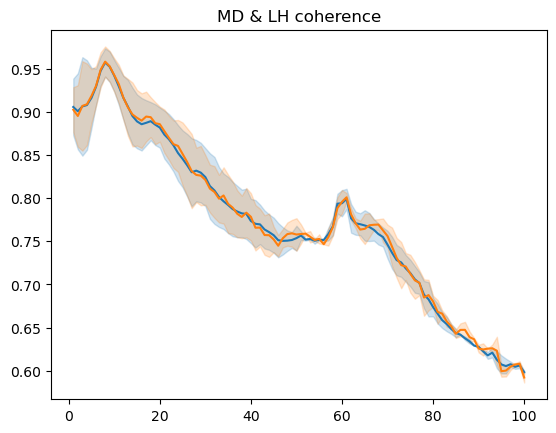

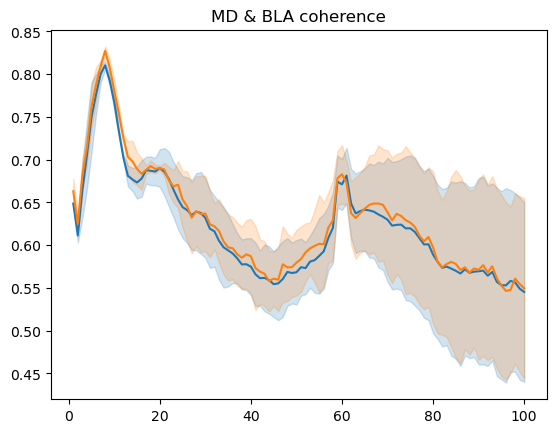

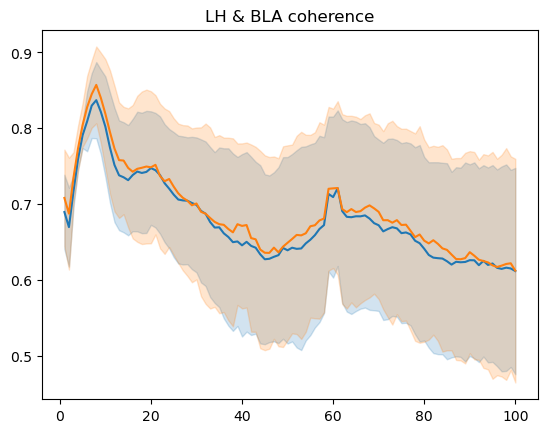

In [ ]:

event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='subject alone',
    events=['selfish light', 'coop light'],
    mode='coherence',
)

### 3. Selfish vs Coop Light for Recipients


Calculating coherence event spectrum for condition(s) ['recipient'] using 4 recording(s).


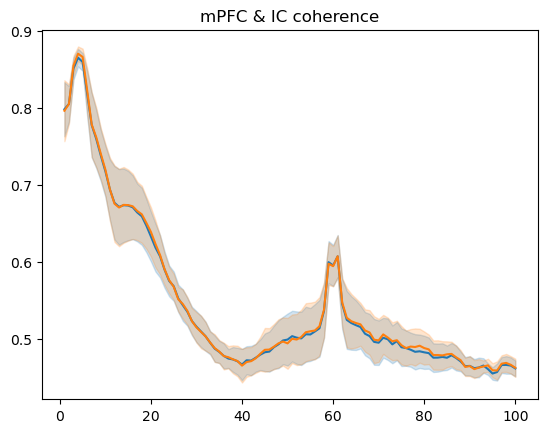

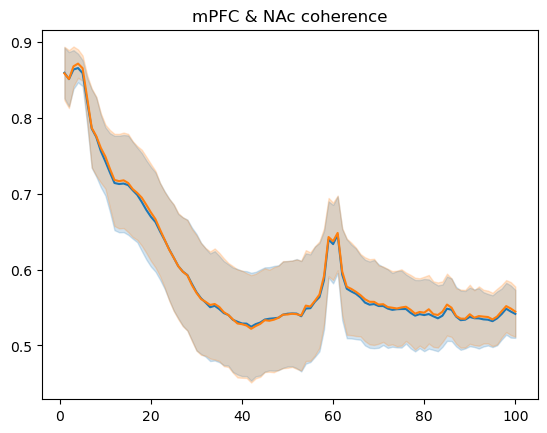

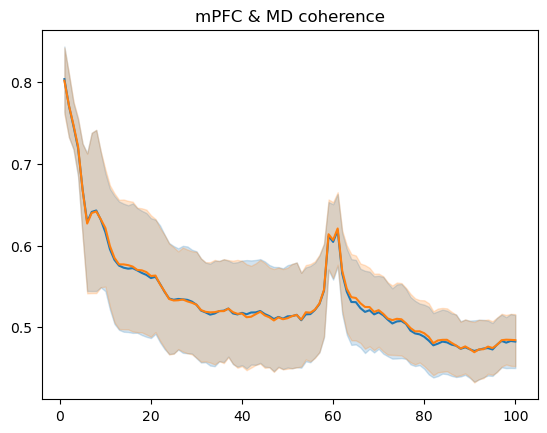

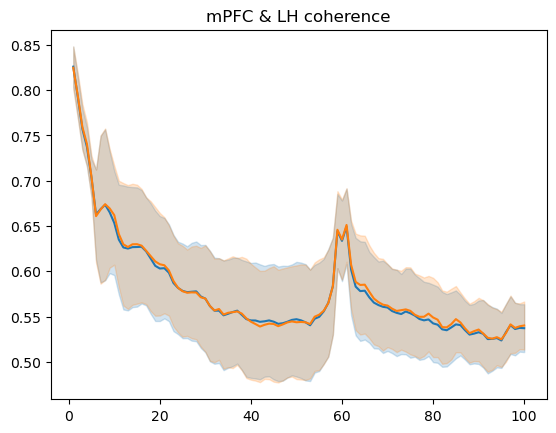

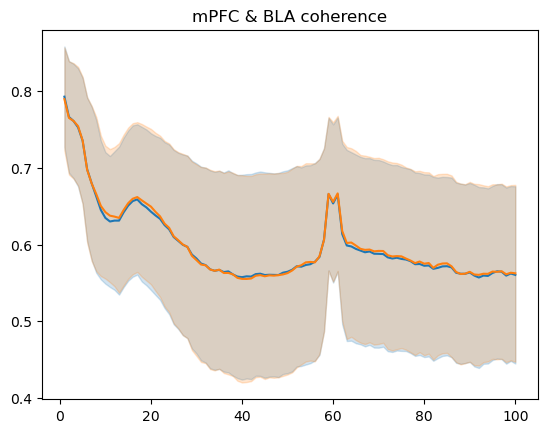

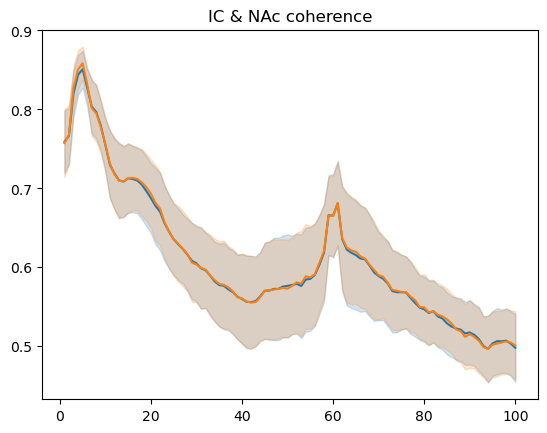

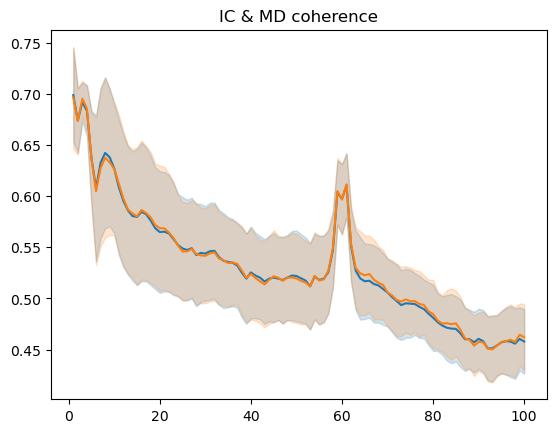

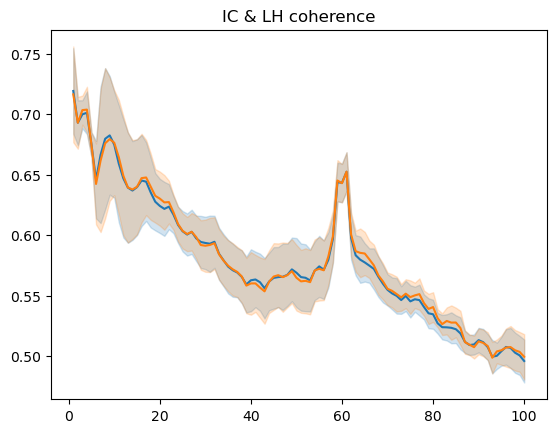

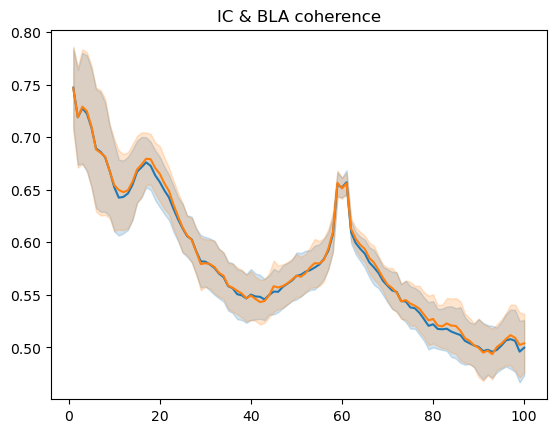

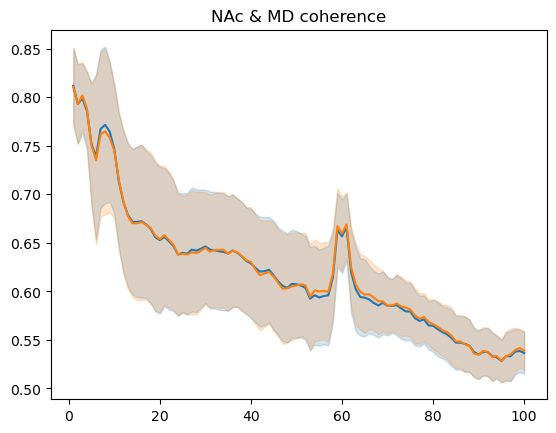

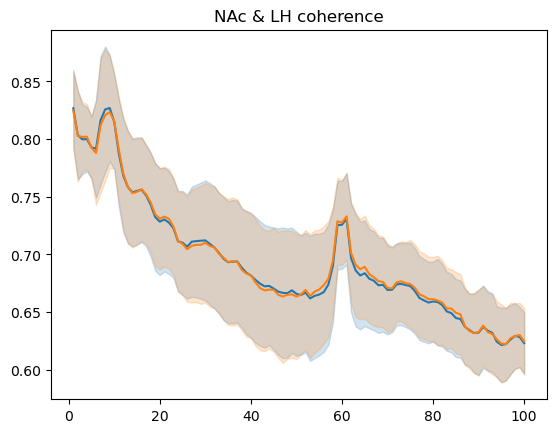

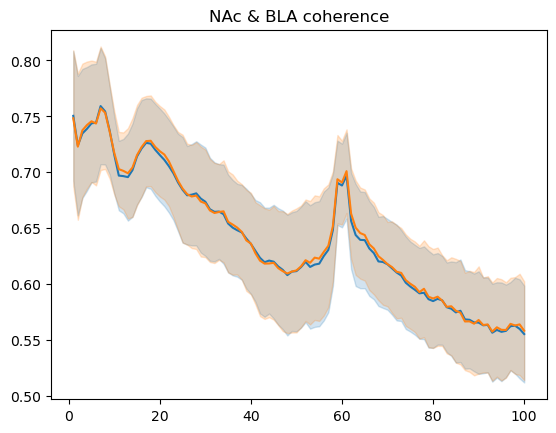

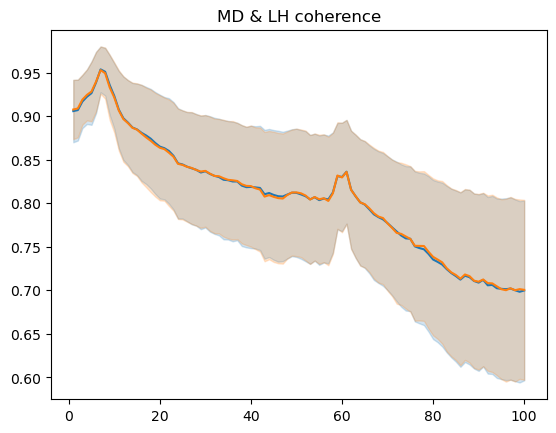

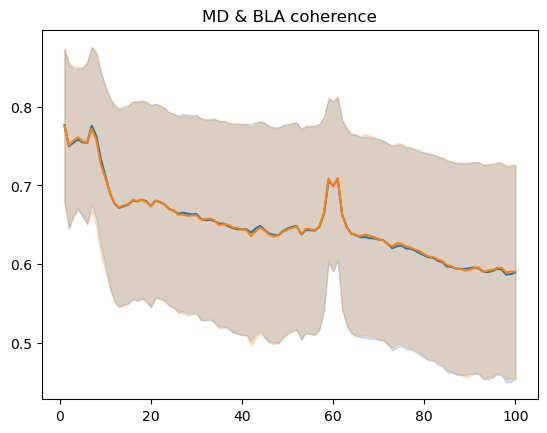

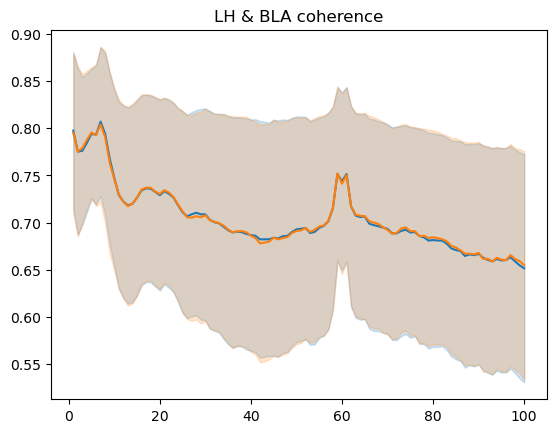

In [ ]:
event_averages = condition_event_spectrum(
    collection,
    condition_recordings=condition_dict,
    selected_condition='recipient',
    events=['selfish light', 'coop light'],
    mode='coherence',
)

## 13. Archived/Exploratory Cells

The remaining commented cells preserve older condition-averaging and plotting attempts. Keep them for provenance, but the active power and coherence workflows are above.


In [ ]:
# # os.chdir('/blue/npadillacoreano/mcum/SocialMemEphys/diff_fam_social_memory_ephys')
# import lfp.lfp_analysis.event_extraction as ee
# def average_events_condition(
#     lfp_collection, events, mode, condition_dict, baseline=None, event_len=None, pre_window=0, post_window=0, plot=False, regions = None, freq_range = None):
#     """
#     Calculates average event measurement (power, coherence, or granger) per recording then
#     calculates global averages across all recordings from recording averages (to account for
#     differences in event numbers per recording)
#     """
#     event_averages_dict = {}
#     recordings = lfp_collection.recordings
#     if baseline is not None:
#         if (len(events) != len(baseline)) and (len(baseline) == 1):
#             baseline = baseline * len(events)
#     for i in range(len(events)):
#         for condition, recording_list in condition_dict.items():
#             recording_averages = []
#             for recording in recordings:
#                 if recording.name in recording_list:
#                     event_averages = ee.get_events(recording, events[i], mode, event_len, pre_window, post_window, average = True)
#                     if baseline is not None:
#                         adj_averages = ee.__baseline_diff__(
#                             recording, event_averages, baseline[i], mode, event_len, pre_window=0, post_window=0, average = True
#                         )
#                         rec_event_average = np.mean(np.array(adj_averages), axis = 0)
#                         recording_averages.append(rec_event_average)
#                     else:
#                         rec_event_average = np.mean(np.array(event_averages), axis = 0)
#                         recording_averages.append(rec_event_average)

#                 # recording_averages = [recs, b, f] or [recs, b, b, f]
#             print(np.array(recording_averages).shape)    
#             event_averages_dict[condition] = recording_averages
#         if plot:
#             lfplt.plot_average_events(lfp_collection, event_averages_dict, mode, regions, freq_range)
#         return event_averages_dict
    
# condition_coherence = average_events_condition(collection, events = ['selfish light'], mode = 'coherence', condition_dict = condition_dict)
# condition_power = average_events_condition(collection, events = ['selfish light'], mode = 'power', condition_dict = condition_dict)

In [ ]:
# del condition_power['recipient']
# del condition_coherence['recipient']

In [ ]:
# import lfp.lfp_analysis.plotting as lfplt
# from importlib import reload
# reload(lfplt)

# lfplt.plot_event_spectrum(collection, condition_power, mode = 'power')
# lfplt.plot_event_spectrum(collection, condition_coherence, mode = 'coherence')

In [ ]:
# def event_power_bar(lfp_collection, events, baseline=None):
#     powers = ee.average_events(lfp_collection, events=events, mode="power", baseline=baseline, plot=False)
#     [unflipped, flipped] = band_calcs(powers)
#     brain_regions = np.empty(len(lfp_collection.brain_region_dict.keys()), dtype="<U10")
#     for i in range(len(lfp_collection.brain_region_dict.keys())):
#         brain_regions[i] = lfp_collection.brain_region_dict.inverse[i]
#     avg_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
#     sem_values = {key: {subset: {event: [] for event in events} for subset in brain_regions} for key in flipped.keys()}
#     for key in flipped.keys():
#         for i, subset in enumerate(brain_regions):
#             for event in events:
#                 avg_values[key][subset][event] = np.nanmean(flipped[key][event][:, i])
#                 sem_values[key][subset][event] = stats.sem(flipped[key][event][:, i], nan_policy="omit")

#     # Adjust bar width and spacing based on number of events
#     total_width = 0.8  # Total width available for each group of bars
#     bar_width = total_width / len(events)  # Width of each bar
#     col = cm.rainbow(np.linspace(0, 1, len(events)))

#     # Spacing between groups of bars
#     group_spacing = 1  # Increased for better separation between brain regions

#     sorted_avg_values = {key: {subset: avg_values[key][subset] for subset in brain_regions} for key in flipped.keys()}
#     sorted_sem_values = {key: {subset: sem_values[key][subset] for subset in brain_regions} for key in flipped.keys()}

#     # Create a separate plot for each key
#     for key in flipped.keys():
#         plt.figure(figsize=(25, 10))
#         x = np.arange(len(brain_regions)) * group_spacing  # x-axis positions for subsets

#         for i, subset in enumerate(brain_regions):
#             for k, event in enumerate(events):
#                 # Center the group of bars and space them evenly
#                 center = x[i]
#                 offset = (k - (len(events) - 1) / 2) * bar_width
#                 position = center + offset

#                 plt.bar(
#                     position,
#                     sorted_avg_values[key][subset][event],
#                     width=bar_width,
#                     yerr=sorted_sem_values[key][subset][event],
#                     capsize=5,
#                     linewidth=2,
#                     error_kw={"elinewidth": 2, "capthick": 2},
#                     color=col[k],
#                     label=event if i == 0 else "",
#                 )

#         plt.yticks(fontsize=20)
#         plt.xticks(x, brain_regions, fontsize=24, rotation=45)
#         plt.axhline(y=0, color="black", linestyle="--", alpha=0.8)
#         plt.gca().spines["top"].set_visible(False)
#         plt.gca().spines["right"].set_visible(False)
#         plt.gca().spines["bottom"].set_linewidth(2)
#         plt.gca().spines["left"].set_linewidth(2)
#         plt.title(f"Average Power for {key}", fontsize=40)
#         plt.legend(fontsize=26, frameon=False)
#         plt.subplots_adjust(hspace=0.5)
#         plt.show()
